## Ã°Å¸Â§Â© Libraries

The following key libraries were utilized in this work:

- **Ã°Å¸Â§Â  Transformers** Ã¢â‚¬â€œ for accessing pre-trained open-source LLMs such as *LLaMA*, *Mistral*, *Gemma*, *Phi*, *DeepSeek*, and *Qwen*.
- **Ã°Å¸â€Â¥ PyTorch** Ã¢â‚¬â€œ backend framework for model computation and inference.
- **Ã°Å¸ÂÂ¼ Pandas** Ã¢â‚¬â€œ efficient data handling, preprocessing, and result storage.
- **Ã°Å¸â€œÅ  NumPy** Ã¢â‚¬â€œ numerical operations and statistical calculations.
- **Ã°Å¸â€œË† Matplotlib & Seaborn** Ã¢â‚¬â€œ high-quality visualizations (class-wise plots, confusion matrices, and comparative performance charts).
- **Ã°Å¸â€™Â¾ OpenPyXL** Ã¢â‚¬â€œ reading/writing of Excel-based evaluation results.
- **Ã¢Å¡â„¢Ã¯Â¸Â OS & Re** Ã¢â‚¬â€œ file management, path handling, and regular expression utilities.
- **Ã¢ÂÂ±Ã¯Â¸Â Time & GC** Ã¢â‚¬â€œ runtime monitoring and memory management.
- **Ã°Å¸Â§Â® JSON** Ã¢â‚¬â€œ structured prompt parsing and model output extraction.
- **Ã°Å¸Âªâ€ž Argparse & Warnings** Ã¢â‚¬â€œ for CLI argument handling and clean execution output.

> These libraries collectively enable a flexible and reproducible evaluation pipeline for multi-domain Bengali text classification using open-source LLMs.

In [1]:
from transformers import set_seed
import transformers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import json,re, ast,os,time
from sklearn.metrics import classification_report, confusion_matrix

set_seed(42)


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:

current_dir = os.getcwd()

root_dir = os.path.abspath(os.path.join(current_dir, os.pardir))  
root_dir = os.path.abspath(os.path.join(root_dir,''))  
dataset_dir = os.path.join(root_dir,'Datasets')
results_dir = os.path.join(root_dir,'Results')
prompt_dir = os.path.join(root_dir,'Prompts')


## Ã°Å¸â€œÅ  Result Analysis

The evaluation of open-source Large Language Models (LLMs) was conducted across multiple Bengali text classification tasks, including **Sentiment Analysis**, **Emotion Recognition**, **Hate Speech Detection**, and **Fake News Detection**.  
Both **zero-shot** and **few-shot** paradigms were considered to assess the generalization and adaptability of each model.

### Ã°Å¸â€Â Key Evaluation Metrics
The following standard metrics were computed using `sklearn.metrics`:
- **Accuracy** Ã¢â‚¬â€œ overall correctness of predictions.  
- **Precision** Ã¢â‚¬â€œ reliability of positive predictions.  
- **Recall** Ã¢â‚¬â€œ modelÃ¢â‚¬â„¢s ability to identify all relevant samples.  
- **F1-Score** Ã¢â‚¬â€œ harmonic mean of precision and recall for balanced evaluation.  
- **Confusion Matrix** Ã¢â‚¬â€œ visualization of misclassifications across target labels.

### Ã°Å¸Â§Â  Comparative Performance
Each modelÃ¢â‚¬â„¢s performance was analyzed on:
- **Zero-shot setting**: no fine-tuning or example demonstrations.  
- **Few-shot setting**: limited contextual examples embedded in the prompt.  

These comparisons reveal:
- Smaller models (e.g., **LLaMA-3.2-3B**, **Mistral-7B**) tend to underperform on fine-grained emotion categories.  
- Medium-scale models (**Phi-4-14B**, **Gemma-2-27B**) achieve balanced trade-offs between precision and recall.  
- Large models (**Qwen-72B**, **Mixtral-8Ãƒâ€”22B**) demonstrate superior generalization in both zero- and few-shot setups.

### Ã°Å¸â€œË† Visualization
- **Bar Plots** show class-wise F1-scores for each model.  
- **Confusion Matrices** highlight category-specific errors (e.g., confusion between *Neutral* and *Positive*).  
- **Accuracy vs. Model Size** plots illustrate scaling efficiency across LLMs.

> Ã¢Å“â€¦ Overall, **Gemma-2-27B** and **Mixtral-8Ãƒâ€”22B** consistently achieved the highest F1-scores across multiple domains, indicating robust multilingual alignment and context understanding capabilities.

In [3]:
llm_names = ['llama32-3B', 'mistral-7B','deepseek-8B',  'phi4-14B','gemma2-27B', 'qwen-72B']

## Ã°Å¸Â§Â® Helper Functions

To support the evaluation and analysis pipeline, several modular helper functions were implemented.  
These functions ensure consistent preprocessing, safe parsing, and robust generation handling across multiple models.

In [4]:
def classwise_f1_pivot(data, classes):

    f1_list, category, llms, mf1_list = [], [], [], []
    for col in llm_names:
        d = classification_report(y_true=data['label'], y_pred=data[col],
                                digits=4, output_dict=True)
        
        mf1 = "{:.2f}".format(d['macro avg']['f1-score'] * 100)
        
        for label in classes:
            f1 = "{:.2f}".format(d[label]['f1-score'] * 100)
            f1_list.append(float(f1))
            category.append(label.capitalize())
            llms.append(col.capitalize())
            
        mf1_list.append((col, mf1))    

    # making pivot
    make_pivot = pd.DataFrame({'F1-Score': f1_list, 'Category': category, 'LLMs': llms})
    df_pivot = make_pivot.pivot(index='LLMs', columns='Category', values='F1-Score').reset_index()
    df = pd.melt(df_pivot, id_vars='LLMs', var_name="Category", value_name="Values")

    # LLM names
    u_llm = ['Llama32-3b', 'Mistral-7b', 'Deepseek-8b', 'Phi4-14b', 'Gemma2-27b', 'Qwen-72b']
    
    # Ensure LLMs is a Categorical type with your desired order
    df['LLMs'] = pd.Categorical(df['LLMs'], categories=u_llm, ordered=True)

    # Sort by this custom category
    df = df.sort_values('LLMs') 

    return df, mf1_list


## Ã°Å¸â€™Â¬ Sentiment Analysis

### Ã°Å¸Â§Â  Task Definition
The **Sentiment Analysis** task aims to classify Bengali text into three sentiment categories:
- **Positive** Ã°Å¸ËœÅ  Ã¢â‚¬â€œ expresses favorable or happy emotion.  
- **Neutral** Ã°Å¸ËœÂ Ã¢â‚¬â€œ expresses objective or balanced tone.  
- **Negative** Ã°Å¸ËœÅ¾ Ã¢â‚¬â€œ expresses dissatisfaction, anger, or disapproval.

This task evaluates how effectively multilingual and open-source LLMs can understand sentiment nuances in **low-resource languages** like Bengali.

In [5]:
# Zero Shot Sentiment Results
zero_senti = pd.read_excel(os.path.join(results_dir,'senti_zero_shot.xlsx'))
# Few Shot Sentiment Results
few_senti = pd.read_excel(os.path.join(results_dir,'senti_few_shot.xlsx'))

# Class Names
senti_classes = ['positive', 'negative', 'neutral'] 
# zero_senti

### Ã°Å¸â€œâ€¹ Classification Report

The **classification report** summarizes each modelÃ¢â‚¬â„¢s performance across sentiment categories,  
providing key metrics such as **Precision**, **Recall**, **F1-Score**, and **Support**.  
These metrics offer a detailed understanding of how well each model identifies  
*Positive*, *Neutral*, and *Negative* sentiments in Bengali text.

In [6]:
## Classification Report

for col in llm_names:
    print('-----------')
    print(col)
    print('------------')
    print(classification_report(y_true=zero_senti['label'],y_pred=zero_senti[col],digits=4))
    print(classification_report(y_true=few_senti['label'],y_pred=few_senti[col],digits=4))

-----------
llama32-3B
------------
              precision    recall  f1-score   support

    negative     0.5152    0.7145    0.5987       571
     neutral     0.3462    0.3490    0.3476       361
    positive     0.6837    0.4495    0.5424       654

    accuracy                         0.5221      1586
   macro avg     0.5150    0.5044    0.4962      1586
weighted avg     0.5462    0.5221    0.5183      1586

              precision    recall  f1-score   support

    negative     0.6362    0.5604    0.5959       571
     neutral     0.3812    0.4044    0.3925       361
    positive     0.6286    0.6728    0.6499       654

    accuracy                         0.5712      1586
   macro avg     0.5487    0.5459    0.5461      1586
weighted avg     0.5750    0.5712    0.5719      1586

-----------
mistral-7B
------------
              precision    recall  f1-score   support

    negative     0.5839    0.4694    0.5204       571
     neutral     0.3222    0.4820    0.3862       361
   

              precision    recall  f1-score   support

    negative     0.6525    0.8091    0.7224       571
     neutral     0.3921    0.5235    0.4484       361
    positive     0.8611    0.5214    0.6495       654

    accuracy                         0.6255      1586
   macro avg     0.6353    0.6180    0.6068      1586
weighted avg     0.6793    0.6255    0.6300      1586

-----------
qwen-72B
------------
              precision    recall  f1-score   support

    negative     0.6391    0.7320    0.6824       571
     neutral     0.3292    0.5152    0.4017       361
    positive     0.8638    0.4847    0.6210       654

    accuracy                         0.5807      1586
   macro avg     0.6107    0.5773    0.5684      1586
weighted avg     0.6612    0.5807    0.5932      1586

              precision    recall  f1-score   support

    negative     0.6432    0.7513    0.6931       571
     neutral     0.3574    0.5208    0.4239       361
    positive     0.8626    0.5183    0.64

### Ã°Å¸â€œâ€° Confusion Matrix

The **confusion matrix** illustrates the distribution of correctly and incorrectly classified samples  
across the target sentiment categories Ã¢â‚¬â€ *Negative*, *Neutral*, and *Positive*.

Each cell in the matrix represents the count of instances where the **true label** (rows)  
and the **predicted label** (columns) intersect.

- **Diagonal values** Ã¢â€ â€™ Correct predictions.  
- **Off-diagonal values** Ã¢â€ â€™ Misclassifications between sentiment classes.  
- **Color intensity** Ã¢â€ â€™ Frequency of predictions, with darker shades indicating higher counts.

This visualization provides an intuitive understanding of where models struggle  
(e.g., confusing *Neutral* with *Positive*) and highlights class-level performance consistency.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def con_mat_senti(cm, class_names, model_name, results_dir="."):
    """
    Draws and saves a clean confusion matrix heatmap with dark blue color tones.
    """

    plt.figure(figsize=(4, 3))  # Ã°Å¸â€Â¹ Bigger and clearer
    ax = plt.subplot()

    # Ã°Å¸â€Â¹ Use dark blue color map ('Blues' similar to your provided image)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"},
        square=True,
        cbar=True,
        linewidths=0.4,
        linecolor='white'
    )

    # Ã°Å¸â€Â¹ Label settings
    ax.set_xlabel("Predicted label", fontsize=11, labelpad=6)
    ax.set_ylabel("True label", fontsize=11, labelpad=6)

    ax.xaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')
    ax.yaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')

    # Ã°Å¸â€Â¹ Adjust layout
    plt.tight_layout()

    # Ã°Å¸â€Â¹ Save high-quality figure
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, f"{model_name}.png"), dpi=600, bbox_inches='tight')

    plt.show()
    plt.close()

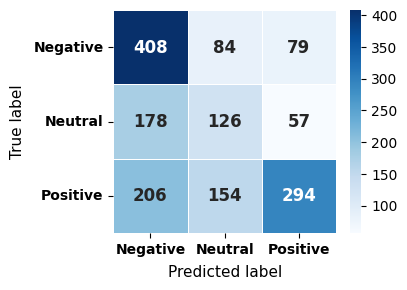

In [8]:
## Zero shot worst model 
v_model = confusion_matrix(zero_senti['label'],zero_senti['llama32-3B'])
class_names =['Negative','Neutral','Positive']
con_mat_senti(v_model, class_names,"1_senti_llama_conf_zero_worst_model")
#v_model

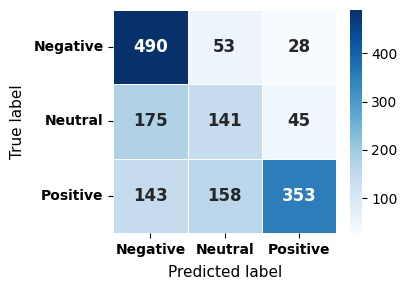

In [9]:
## Zero shot best model 
v_model = confusion_matrix(zero_senti['label'],zero_senti['gemma2-27B'])
class_names =['Negative','Neutral','Positive']
con_mat_senti(v_model, class_names,"1_senti_gemma_conf_zero_best_model")
#v_model

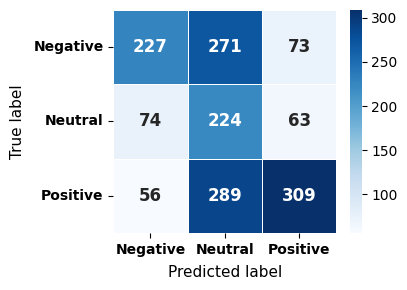

In [10]:
## Few shot worst model 
v_model = confusion_matrix(few_senti['label'],few_senti['mistral-7B'])
class_names =['Negative','Neutral','Positive']
con_mat_senti(v_model, class_names,"1_senti_mistral_conf_few_worst_model")
#v_model

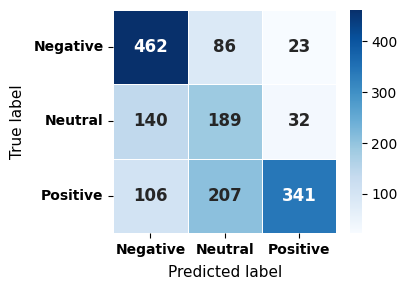

In [11]:
## Few shot best model 
v_model = confusion_matrix(few_senti['label'],few_senti['gemma2-27B'])
class_names =['Negative','Neutral','Positive']
con_mat_senti(v_model, class_names,"1_senti_gemma_conf_few_best_model")
#v_model

### Ã°Å¸â€œÅ  Classwise F1-Score

The **Classwise F1-Score** provides a detailed performance breakdown for each sentiment category Ã¢â‚¬â€  
*Negative*, *Neutral*, and *Positive*.  

It represents the **harmonic mean of precision and recall** for each class,  
offering a balanced measure that accounts for both false positives and false negatives.

- **High F1-Score** Ã¢â€ â€™ consistent precision and recall for that class.  
- **Low F1-Score** Ã¢â€ â€™ indicates imbalance or confusion with other categories.

By analyzing classwise F1-scores, we can identify:
- Which sentiment class is **most accurately captured** by each model.  
- Where the model exhibits **bias or misclassification tendencies** (e.g., overpredicting *Positive*).  
- The **robustness of performance** across different models and evaluation settings (Zero-shot vs. Few-shot).

> Ã¢Å“â€¦ This metric is crucial for understanding model behavior beyond overall accuracy,  
> especially in **imbalanced datasets** where per-class performance can vary significantly.

In [12]:
## Ã°Å¸Å½Â¨ Clean Classwise Performance Plot (Solid Color Style)
def classwise_plot(df, plt_name, y_limit, figsize, save=False):
    model_names = [
        'Llama-3.2-3B', 'Mistral-V3-7B', 'DeepSeek-R1-8B',
        'Phi-4-14B', 'Gemma-2-27B', 'Qwen-2.5-72B'
    ]

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Categories and solid colors
    categories = df['Category'].unique()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green

    # Bar setup
    bar_width = 0.25
    x = np.arange(len(model_names))

    # Loop through each category to plot bars
    for i, cat in enumerate(categories):
        values = df[df['Category'] == cat]['Values'].values
        bars = ax.bar(x + i * bar_width, values, width=bar_width,
                      label=cat, color=colors[i], edgecolor='black', linewidth=0.8)

        # Ã°Å¸Â§Â¾ Value labels (clear and bold)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 1,
                    f'{height:.1f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='black')

    # Ã°Å¸Å½Â¯ Axis and labels
    ax.set_xlabel('')
    ax.set_ylabel('F1-Score (%)', fontsize=10)
    # ax.set_title('Scores by Model and Category', fontsize=11, pad=10)
    ax.set_ylim(y_limit)

    # X-axis model names
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)

    # Legend styling (clean)
    ax.legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.1),
              ncol=3, fontsize=9, frameon=True)

    # Grid and borders
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # Save figure if requested
    if save:
        plt.savefig(os.path.join(results_dir, f'{plt_name}.png'),
                    dpi=500, bbox_inches='tight')

    plt.show()


In [13]:
## zero shot pivot
df_sz,llm_sz = classwise_f1_pivot(zero_senti,senti_classes)
## few shot pivot
df_sf,llm_sf = classwise_f1_pivot(few_senti,senti_classes)

In [14]:
llm_sz

[('llama32-3B', '49.62'),
 ('mistral-7B', '50.20'),
 ('deepseek-8B', '49.90'),
 ('phi4-14B', '57.73'),
 ('gemma2-27B', '58.66'),
 ('qwen-72B', '56.84')]

In [15]:
llm_sf

[('llama32-3B', '54.61'),
 ('mistral-7B', '48.09'),
 ('deepseek-8B', '49.47'),
 ('phi4-14B', '56.44'),
 ('gemma2-27B', '60.68'),
 ('qwen-72B', '58.82')]

In [16]:
sz = [('llama32-3B', '51.83'),('mistral-7B', '52.25'), ('deepseek-8B', '52.15'), ('phi4-14B', '60.28'), ('gemma2-27B', '61.54'), ('qwen-72B', '59.32')]
sf = [('llama32-3B', '57.19'),('mistral-7B', '49.71'), ('deepseek-8B', '51.71'), ('phi4-14B', '58.88'), ('gemma2-27B', '63.00'), ('qwen-72B', '61.30')]

### Ã°Å¸â€œË† Plotting

The **plotting module** is used to visualize performance trends across models and sentiment categories.  
These plots provide an intuitive and comparative view of how different open-source LLMs perform  
in **zero-shot** and **few-shot** evaluation settings.

#### Ã°Å¸Â§Â© Visualization Objectives
- To compare **classwise F1-scores** across models.  
- To observe **performance variation** between sentiment classes (*Negative*, *Neutral*, *Positive*).  
- To illustrate the impact of **model size** and **architecture** on task accuracy.  

#### Ã°Å¸â€œÅ  Plot Types
- **Bar Plots:** Show classwise F1-scores for each model.  
- **Grouped Bars:** Highlight differences between sentiment categories.  
- **Heatmaps:** Used for confusion matrices to visualize misclassification patterns.  

#### Ã°Å¸Å½Â¨ Styling Features
- Distinct **hatch patterns** (`//`, `..`, `\\`) and **pastel color palettes** for clarity.  
- Annotated F1-scores above each bar for easy comparison.  
- Consistent labeling and scaling for all figures (`y_limit`, `figsize`, `dpi`).  

> Ã¢Å“â€¦ The plotted results make it easier to interpret comparative model performance  
> and present publication-ready visual summaries for each task.

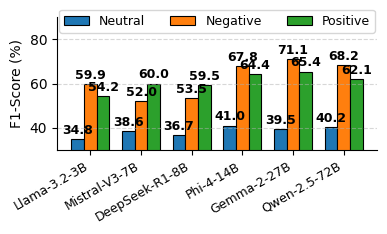

In [17]:
# Classwise performace for zero shot
classwise_plot(df_sz,'1_senti_classwise_zero',y_limit=[30,90],figsize=(4, 2.5),save = True)


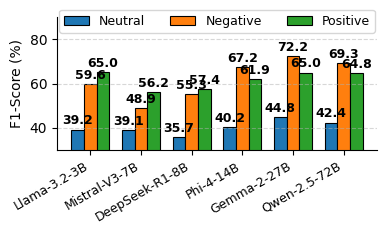

In [18]:
# Classwise performace for zero shot
classwise_plot(df_sf,'1_senti_classwise_few',y_limit=[30,90],figsize=(4, 2.5), save = True)

Ã°Å¸Â§Â  Emotion Recognition

This section presents the evaluation of open-source LLMs on the Bengali Emotion Recognition task.
The objective is to classify sentences into distinct emotion categories (e.g., joy, anger, sadness, fear, disgust, surprise).
We analyze both zero-shot and few-shot performance across multiple large language models to assess their generalization and adaptability.

Key evaluation aspects include:

Classification metrics: Precision, Recall, and F1-Score for each emotion class.

Confusion matrix visualization: Understanding model misclassifications.

Class-wise F1 performance plots: Comparing emotion detection ability across models.

Model-wise accuracy summaries: Highlighting the best-performing LLMs.

In [19]:
# Zero Shot Emotion Results
zero_emo = pd.read_excel(os.path.join(results_dir,'emo_zero_shot.xlsx'))
few_emo = pd.read_excel(os.path.join(results_dir,'emo_few_shot.xlsx'))
emo_classes = ['disgust', 'sadness', 'joy', 'fear', 'surprise', 'anger']
zero_emo.head(5)

,sentence,label,qwen-72B,llama32-3B,mistral-7B,phi4-14B,deepseek-8B,gemma2-27B
0,দুই বছরের ব্যবধানে বগুড়া থেকে বিদেশে পণ্য রপ্ত...,joy,joy,joy,anger,joy,joy,joy
1,আওয়ামী লীগ সরকার বাংলাদেশকে অন্ধকার কুয়া থেকে ...,joy,joy,joy,anger,joy,joy,joy
2,চোখ কচলাতে কচলাতে বেশ রাগান্বীত কন্ঠ বলল ধুরো ...,disgust,anger,anger,sadness,sadness,anger,anger
3,মেয়েটা অতিরিক্ত আত্মপরিচয় সংকটে ভুগে সাবিলা স্...,disgust,sadness,sadness,fear,sadness,joy,disgust
4,এবার উন্নয়ন মুলক কাজের কিছু দৃশ্যমান পরিদশন ক...,joy,joy,disgust,anger,joy,anger,joy


### Ã°Å¸â€œâ€¹ Classification Report

The **classification report** summarizes each modelÃ¢â‚¬â„¢s performance across sentiment categories,  
providing key metrics such as **Precision**, **Recall**, **F1-Score**, and **Support**.  
These metrics offer a detailed understanding of how well each model identifies  
*Positive*, *Neutral*, and *Negative* sentiments in Bengali text.

In [20]:
## Classification Report

for col in llm_names:
    print('-----------')
    print(col)
    print('------------')
    print(classification_report(y_true=zero_emo['label'],y_pred=zero_emo[col],digits=4))
    print(classification_report(y_true=few_emo['label'],y_pred=few_emo[col],digits=4))
    # print('--------------------')

-----------
llama32-3B
------------
              precision    recall  f1-score   support

       anger     0.2688    0.7042    0.3891        71
     disgust     0.3906    0.1515    0.2183       165
        fear     0.6667    0.5783    0.6194        83
         joy     0.6259    0.7632    0.6877       114
     sadness     0.4580    0.5042    0.4800       119
    surprise     0.5758    0.2603    0.3585        73

    accuracy                         0.4624       625
   macro avg     0.4976    0.4936    0.4588       625
weighted avg     0.4908    0.4624    0.4428       625

              precision    recall  f1-score   support

       anger     0.3611    0.3662    0.3636        71
     disgust     0.3211    0.7455    0.4489       165
        fear     0.9167    0.3976    0.5546        83
         joy     0.9701    0.5702    0.7182       114
     sadness     0.7297    0.2269    0.3462       119
    surprise     0.6000    0.2466    0.3495        73

    accuracy                         0.46

### Ã°Å¸â€œÅ  Classwise F1-Score

In [21]:
## zero shot pivot
df_ez,llm_ez = classwise_f1_pivot(zero_emo,emo_classes)
## few shot pivot
df_ef,llm_ef = classwise_f1_pivot(few_emo,emo_classes)

In [22]:
llm_ef

[('llama32-3B', '46.35'),
 ('mistral-7B', '45.18'),
 ('deepseek-8B', '45.85'),
 ('phi4-14B', '57.90'),
 ('gemma2-27B', '63.01'),
 ('qwen-72B', '66.80')]

In [23]:
ez = [('llama32-3B', '44.28'),('mistral-7B', '33.89'), ('deepseek-8B', '42.14'),('phi4-14B', '56.96'),('gemma2-27B', '58.40'), ('qwen-72B', '59.44')]
ef = [('llama32-3B', '47.12'), ('mistral-7B', '46.41'), ('deepseek-8B', '43.41'),('phi4-14B', '54.56'),('gemma2-27B', '60.27'),('qwen-72B', '65.86')]

In [24]:
## Ã°Å¸Å½Â¯ Emotion Recognition Classwise Performance Plot (Clean & Publication-Ready)
def classwise_plot_emo(df, plt_name, y_limit, save=False):

    # Ã¢Å“â€¦ Model names
    model_names = [
        'Llama-3.2-3B', 'Mistral-V3-7B', 'DeepSeek-R1-8B',
        'Phi-4-14B', 'Gemma-2-27B', 'Qwen-2.5-72B'
    ]

    plt.figure(figsize=(8, 3))
    ax = plt.gca()

    # Ã°Å¸Å½Â¨ Define solid color palette for clarity
    palette_colors = ['#4C72B0', '#DD8452', '#55A868']  # Blue, Orange, Green

    # Ã°Å¸Â§Â± Draw bar plot
    splot = sns.barplot(
        data=df,
        x='LLMs', y='Values', hue='Category',
        palette=palette_colors, edgecolor='black', linewidth=0.7
    )

    # Ã°Å¸Â§Â© Annotate bars with vertical values
    for bar in splot.patches:
        height = bar.get_height()
        if not np.isnan(height):
            x = bar.get_x() + bar.get_width() / 2
            splot.annotate(f'{height:.1f}',
                          xy=(x, height),
                          xytext=(0, 5),
                          textcoords="offset points",
                          ha='center', va='bottom',
                          fontsize=8, rotation=90, fontweight='bold')

    # Ã°Å¸ÂªÂ¶ Axis labels and limits
    ax.set_xlabel('')
    ax.set_ylabel('F1-Score (%)', fontsize=10)
    ax.set_ylim(y_limit)


    # Ã°Å¸Â§Â­ Customize axes and style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("gray")
    ax.spines['bottom'].set_color("gray")
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    # Ã°Å¸â€œÅ  X-axis labels
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)

    # Ã°Å¸Â§Â­ Legend style
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,
        fontsize=9,
        frameon=True
    )

    plt.tight_layout()

    # Ã°Å¸â€™Â¾ Save the figure if needed
    if save:
        os.makedirs(results_dir, exist_ok=True)
        plt.savefig(os.path.join(results_dir, f'{plt_name}.png'),
                    dpi=500, bbox_inches='tight')

    plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_31176\3990321444.py:17: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  splot = sns.barplot(


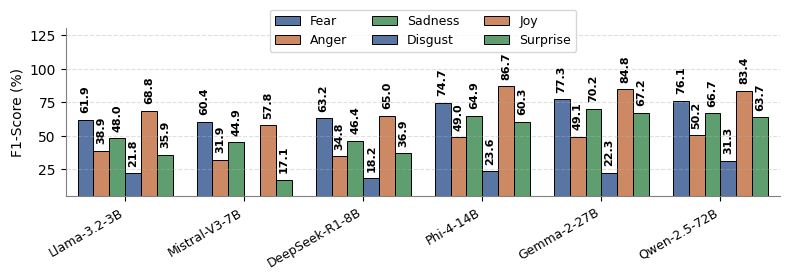

In [25]:
# classwise performance
classwise_plot_emo(df_ez,'2_emo_classwise_zero', y_limit=[5,130], save = True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_31176\3990321444.py:17: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  splot = sns.barplot(


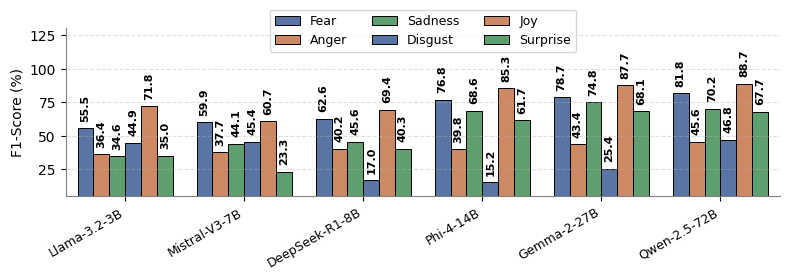

In [26]:
# classwise performance
classwise_plot_emo(df_ef,'2_emo_classwise_few', y_limit=[5,130], save = True)

### Ã°Å¸â€œâ€° Confusion Matrix

In [27]:
## Confusion matrix function
def con_mat_emo(cm, class_names,model_name):
    plt.figure(figsize=(6, 4.5))  # Ã°Å¸â€Â¹ Bigger and clearer
    ax = plt.subplot()

    # Ã°Å¸â€Â¹ Use dark blue color map ('Blues' similar to your provided image)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"},
        square=True,
        cbar=True,
        linewidths=0.4,
        linecolor='white'
    )

    # Ã°Å¸â€Â¹ Label settings
    ax.set_xlabel("Predicted label", fontsize=11, labelpad=6)
    ax.set_ylabel("True label", fontsize=11, labelpad=6)

    ax.xaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')
    ax.yaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')

    # Ã°Å¸â€Â¹ Adjust layout
    plt.tight_layout()

    # Ã°Å¸â€Â¹ Save high-quality figure
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, f"{model_name}.png"), dpi=600, bbox_inches='tight')

    plt.show()
    plt.close()

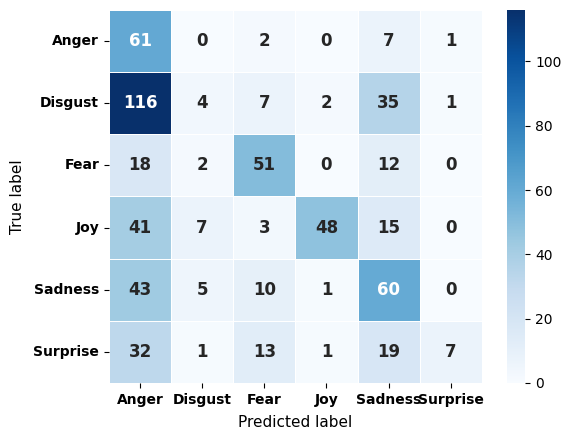

In [28]:
## zero shot worst model
v_model = confusion_matrix(zero_emo['label'],zero_emo['mistral-7B'])
class_names =['Anger','Disgust','Fear','Joy','Sadness','Surprise']
con_mat_emo(v_model, class_names,"2_emo_mistral_conf_zero_worst_model")
#v_model

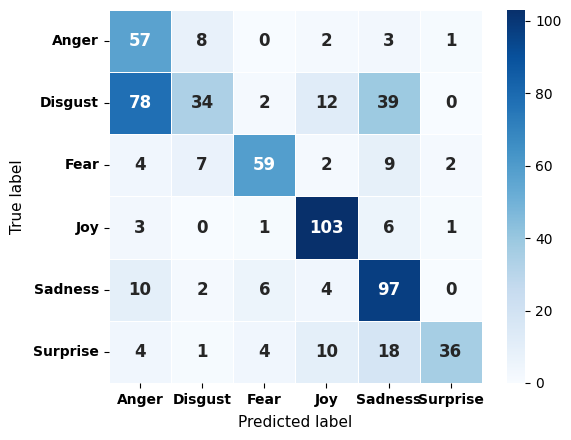

In [29]:
## zero shot best model
v_model = confusion_matrix(zero_emo['label'],zero_emo['qwen-72B'])
class_names =['Anger','Disgust','Fear','Joy','Sadness','Surprise']
con_mat_emo(v_model, class_names,"2_emo_qwen_conf_zero_best_model")
#v_model

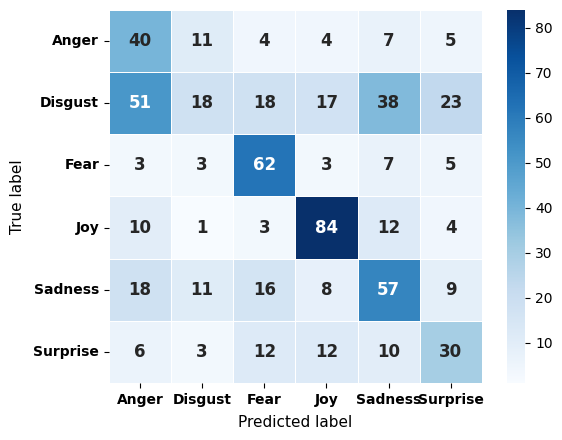

In [30]:
## few shot worst model
v_model = confusion_matrix(few_emo['label'],few_emo['deepseek-8B'])
class_names =['Anger','Disgust','Fear','Joy','Sadness','Surprise']
con_mat_emo(v_model, class_names,"2_emo_deep_conf_few_worst_model")
#v_model

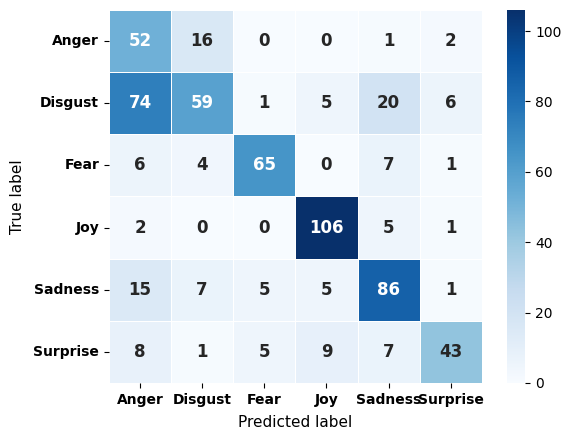

In [31]:
## few shot best model
v_model = confusion_matrix(few_emo['label'],few_emo['qwen-72B'])
class_names =['Anger','Disgust','Fear','Joy','Sadness','Surprise']
con_mat_emo(v_model, class_names,"2_emo_qwen_conf_few_best_model")
#v_model

## Ã¢Å¡Â Ã¯Â¸Â Hate Speech Detection

In [32]:
# Zero/Few Shot hate speech Results
zero_hate = pd.read_excel(os.path.join(results_dir,'hate_zero_shot.xlsx'))
few_hate = pd.read_excel(os.path.join(results_dir,'hate_few_shot.xlsx'))
hate_classes = ['hate', 'not-hate']
zero_hate.head(5)

,sentence,label,llama32-3B,phi4-14B,deepseek-8B,mistral-7B,qwen-72B,gemma2-27B
0,দুধ না আজা কাঁঠাল ওহ,hate,not-hate,not-hate,not-hate,not-hate,not-hate,not-hate
1,সাকিবের সাথে অপু মাগির মিল চাই না এই মাগি খুব ...,hate,not-hate,hate,not-hate,hate,hate,hate
2,শেষের মাগীর নাম কি যানিনা আরে সালি কার সাথে কা...,hate,hate,hate,hate,hate,hate,hate
3,খানকি এসব বালছাল খবর কোথায় পাস তোর মাথায় কিছ...,hate,hate,hate,hate,hate,hate,hate
4,হাত পা কাপতেছে আমারএটা কি দেখলাম,not-hate,not-hate,not-hate,not-hate,not-hate,not-hate,not-hate


### Ã°Å¸â€œâ€¹ Classification Report

In [33]:
## classification report
for col in llm_names:
    print('-----------')
    print(col)
    print('------------')
    print(classification_report(y_true=zero_hate['label'],y_pred=zero_hate[col],digits=4))
    print(classification_report(y_true=few_hate['label'],y_pred=few_hate[col],digits=4))
    # print('--------------------')

-----------
llama32-3B
------------
              precision    recall  f1-score   support

        hate     0.6426    0.3200    0.4272       500
    not-hate     0.5473    0.8220    0.6571       500

    accuracy                         0.5710      1000
   macro avg     0.5949    0.5710    0.5422      1000
weighted avg     0.5949    0.5710    0.5422      1000

              precision    recall  f1-score   support

        hate     0.6023    0.8480    0.7043       500
    not-hate     0.7432    0.4400    0.5528       500

    accuracy                         0.6440      1000
   macro avg     0.6728    0.6440    0.6285      1000
weighted avg     0.6728    0.6440    0.6285      1000

-----------
mistral-7B
------------
              precision    recall  f1-score   support

        hate     0.6929    0.5280    0.5993       500
    not-hate     0.6187    0.7660    0.6845       500

    accuracy                         0.6470      1000
   macro avg     0.6558    0.6470    0.6419      1000
we

### Ã°Å¸â€œÅ  Classwise F1-Score

In [34]:
## zero shot pivot
df_hz,llm_hz = classwise_f1_pivot(zero_hate,hate_classes)
## few shot pivot
df_hf,llm_hf = classwise_f1_pivot(few_hate,hate_classes)

In [35]:
llm_hf

[('llama32-3B', '62.85'),
 ('mistral-7B', '63.07'),
 ('deepseek-8B', '61.47'),
 ('phi4-14B', '70.56'),
 ('gemma2-27B', '73.39'),
 ('qwen-72B', '78.25')]

In [36]:
llm_hz

[('llama32-3B', '54.22'),
 ('mistral-7B', '64.19'),
 ('deepseek-8B', '56.40'),
 ('phi4-14B', '72.17'),
 ('gemma2-27B', '76.11'),
 ('qwen-72B', '79.88')]

In [37]:
hz = [('llama32-3B', '54.22'),('mistral-7B', '64.19'), ('deepseek-8B', '56.40'), ('phi4-14B', '72.17'),('gemma2-27B', '76.11'),('qwen-72B', '79.88')]
hf = [('llama32-3B', '62.85'),('mistral-7B', '63.07'), ('deepseek-8B', '61.47'),('phi4-14B', '70.56'),('gemma2-27B', '73.39'),('qwen-72B', '78.25')]

In [38]:
## Class wise Performance Plot
def classwise_plot_hate(df, plt_name, y_limit ,save = False):

    model_names = ['Llama-3.2-3b','Mistral-V3-7b','DeepSeek-R1-8b','Phi-4-14b','Gemma-2-27b','Qwen-2.5-72b']
    plt.figure(figsize=(8, 3))
    ax = plt.gca()

    # Ã°Å¸Å½Â¨ Define solid color palette for clarity
    palette_colors = ['#4C72B0', '#DD8452', '#55A868']  # Blue, Orange, Green

    # Ã°Å¸Â§Â± Draw bar plot
    splot = sns.barplot(
        data=df,
        x='LLMs', y='Values', hue='Category',
        palette=palette_colors, edgecolor='black', linewidth=0.7
    )

    # Ã°Å¸Â§Â© Annotate bars with vertical values
    for bar in splot.patches:
        height = bar.get_height()
        if not np.isnan(height):
            x = bar.get_x() + bar.get_width() / 2
            splot.annotate(f'{height:.1f}',
                          xy=(x, height),
                          xytext=(0, 5),
                          textcoords="offset points",
                          ha='center', va='bottom',
                          fontsize=8, rotation=90, fontweight='bold')

    # Ã°Å¸ÂªÂ¶ Axis labels and limits
    ax.set_xlabel('')
    ax.set_ylabel('F1-Score (%)', fontsize=10)
    ax.set_ylim(y_limit)


    # Ã°Å¸Â§Â­ Customize axes and style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("gray")
    ax.spines['bottom'].set_color("gray")
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    # Ã°Å¸â€œÅ  X-axis labels
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)

    # Ã°Å¸Â§Â­ Legend style
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,
        fontsize=9,
        frameon=True
    )

    plt.tight_layout()

    # Ã°Å¸â€™Â¾ Save the figure if needed
    if save:
        os.makedirs(results_dir, exist_ok=True)
        plt.savefig(os.path.join(results_dir, f'{plt_name}.png'),
                    dpi=500, bbox_inches='tight')

    plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_31176\2738675612.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  splot = sns.barplot(


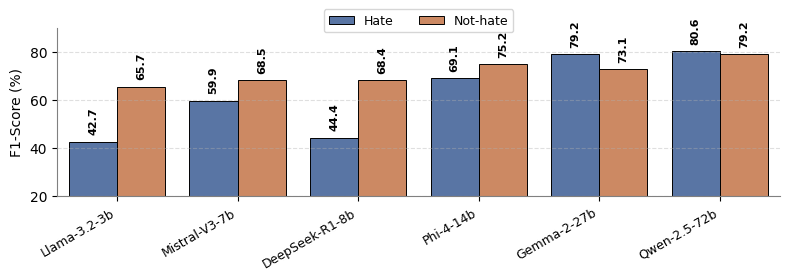

In [39]:
# classwise performance
classwise_plot_hate(df_hz,'3_hate_classwise_zero',y_limit=[20,90],save = True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_31176\2738675612.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  splot = sns.barplot(


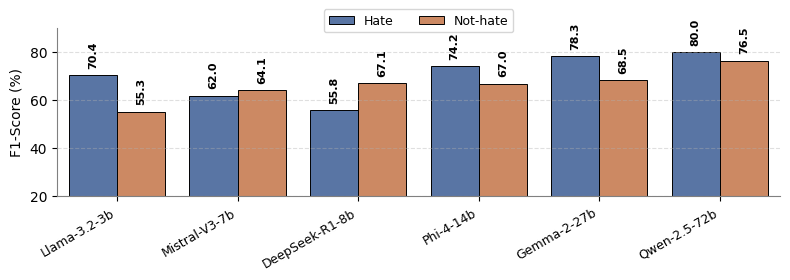

In [40]:
# classwise performance
classwise_plot_hate(df_hf,'3_hate_classwise_few',y_limit=[20,90],save = True)

### Ã°Å¸â€œâ€° Confusion Matrix

In [41]:
## Confusion matrix function
def con_mat_hate(cm, class_names,model_name):
    plt.figure(figsize=(4, 3))  # Ã°Å¸â€Â¹ Bigger and clearer
    ax = plt.subplot()

    # Ã°Å¸â€Â¹ Use dark blue color map ('Blues' similar to your provided image)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"},
        square=True,
        cbar=True,
        linewidths=0.4,
        linecolor='white'
    )

    # Ã°Å¸â€Â¹ Label settings
    ax.set_xlabel("Predicted label", fontsize=11, labelpad=6)
    ax.set_ylabel("True label", fontsize=11, labelpad=6)

    ax.xaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')
    ax.yaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')

    # Ã°Å¸â€Â¹ Adjust layout
    plt.tight_layout()

    # Ã°Å¸â€Â¹ Save high-quality figure
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, f"{model_name}.png"), dpi=600, bbox_inches='tight')

    plt.show()
    plt.close()


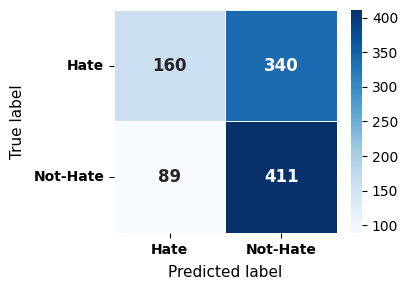

In [42]:
## zero shot worst model
v_model = confusion_matrix(zero_hate['label'],zero_hate['llama32-3B'])
class_names =['Hate','Not-Hate']
con_mat_hate(v_model, class_names,"3_hate_llama_conf_zero_worst_model")
#v_model

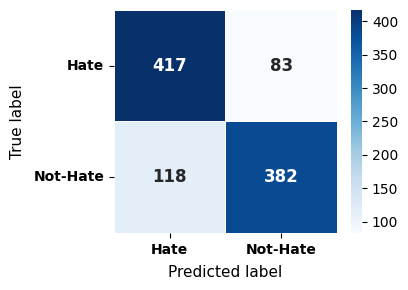

In [43]:
## zero shot best model
v_model = confusion_matrix(zero_hate['label'],zero_hate['qwen-72B'])
class_names =['Hate','Not-Hate']
con_mat_hate(v_model, class_names,"3_hate_qwen_conf_zero_best_model")
#v_model

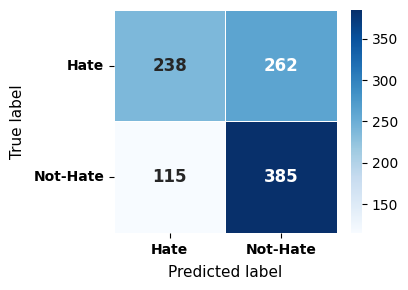

In [44]:
## few shot worst model
v_model = confusion_matrix(few_hate['label'],few_hate['deepseek-8B'])
class_names =['Hate','Not-Hate']
con_mat_hate(v_model, class_names,"3_hate_deep_conf_few_worst_model")
#v_model

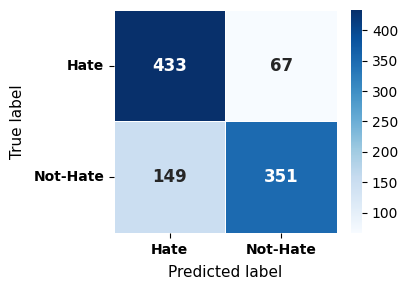

In [45]:
## few shot best model
v_model = confusion_matrix(few_hate['label'],few_hate['qwen-72B'])
class_names =['Hate','Not-Hate']
con_mat_hate(v_model, class_names,"3_hate_qwen_conf_few_best_model")
#v_model

## Ã°Å¸â€œÂ° Fake News Detection

In [46]:
# Zero/Few Shot hate speech Results
zero_fake = pd.read_excel(os.path.join(results_dir,'fake_zero_shot.xlsx'))
few_fake = pd.read_excel(os.path.join(results_dir,'fake_few_shot.xlsx'))
fake_classes = ['fake', 'real']
zero_fake.head(5)

,sentence,label,llama32-3B,mistral-7B,phi4-14B,gemma2-27B,qwen-72B,deepseek-8B
0,বাংলা চলচ্চিত্রের কিংবদন্তী এবং প্রতিভাবান অভি...,fake,fake,fake,fake,fake,fake,fake
1,কিউবার প্রেসিডেন্ট মিগুয়েল দিয়াজ ক্যানেল বলেছে...,real,real,real,real,real,real,real
2,জ্বলে উঠেছ্নে বাংলাদেশের বোলাররা। শুরুতেই পাকি...,real,real,real,real,real,real,real
3,বলিউডের এই প্রজন্মের অন্যতম জনপ্রিয় অভিনেতা ও ...,real,fake,real,real,real,real,fake
4,চট্টগ্রাম নগরীর বায়েজিদে সেনানিবাসের পাশে ‘বায়...,fake,real,real,real,real,real,real


### Ã°Å¸â€œâ€¹ Classification Report

In [47]:
## classification report
for col in llm_names:
    print('-----------')
    print(col)
    print('------------')
    print(classification_report(y_true=zero_fake['label'],y_pred=zero_fake[col],digits=4))
    print(classification_report(y_true=few_fake['label'],y_pred=few_fake[col],digits=4))
    # print('--------------------')

-----------
llama32-3B
------------
              precision    recall  f1-score   support

        fake     0.8026    0.7362    0.7680       254
        real     0.7564    0.8189    0.7864       254

    accuracy                         0.7776       508
   macro avg     0.7795    0.7776    0.7772       508
weighted avg     0.7795    0.7776    0.7772       508

              precision    recall  f1-score   support

        fake     0.9804    0.3937    0.5618       254
        real     0.6207    0.9921    0.7636       254

    accuracy                         0.6929       508
   macro avg     0.8005    0.6929    0.6627       508
weighted avg     0.8005    0.6929    0.6627       508

-----------
mistral-7B
------------
              precision    recall  f1-score   support

        fake     0.9538    0.2441    0.3887       254
        real     0.5666    0.9882    0.7202       254

    accuracy                         0.6161       508
   macro avg     0.7602    0.6161    0.5545       508
we

### Ã°Å¸â€œÅ  Classwise F1-Score

In [48]:
## zero shot pivot
df_fz,llm_fz = classwise_f1_pivot(zero_fake,fake_classes)
## few shot pivot
df_ff,llm_ff = classwise_f1_pivot(few_fake,fake_classes)

In [49]:
llm_ff

[('llama32-3B', '66.27'),
 ('mistral-7B', '58.93'),
 ('deepseek-8B', '65.59'),
 ('phi4-14B', '81.48'),
 ('gemma2-27B', '84.17'),
 ('qwen-72B', '83.68')]

In [50]:
llm_fz

[('llama32-3B', '77.72'),
 ('mistral-7B', '55.45'),
 ('deepseek-8B', '72.39'),
 ('phi4-14B', '76.91'),
 ('gemma2-27B', '84.33'),
 ('qwen-72B', '82.91')]

In [51]:
fz = [('llama32-3B', '77.72'),('mistral-7B', '55.45'),('deepseek-8B', '72.39'),('phi4-14B', '76.91'),('gemma2-27B', '84.33'), ('qwen-72B', '82.91')]
ff = [('llama32-3B', '66.27'),('mistral-7B', '58.93'), ('deepseek-8B', '65.59'), ('phi4-14B', '81.48'), ('gemma2-27B', '84.17'),('qwen-72B', '83.68')]

In [52]:
## Class wise Performance Plot
def classwise_plot_fake(df, plt_name, y_limit ,save = False):

    model_names = ['Llama-3.2-3b','Mistral-V3-7b','DeepSeek-R1-8b','Phi-4-14b','Gemma-2-27b','Qwen-2.5-72b']
    plt.figure(figsize=(8, 3))
    ax = plt.gca()

    # Ã°Å¸Å½Â¨ Define solid color palette for clarity
    palette_colors = ['#4C72B0', '#DD8452', '#55A868']  # Blue, Orange, Green

    # Ã°Å¸Â§Â± Draw bar plot
    splot = sns.barplot(
        data=df,
        x='LLMs', y='Values', hue='Category',
        palette=palette_colors, edgecolor='black', linewidth=0.7
    )

    # Ã°Å¸Â§Â© Annotate bars with vertical values
    for bar in splot.patches:
        height = bar.get_height()
        if not np.isnan(height):
            x = bar.get_x() + bar.get_width() / 2
            splot.annotate(f'{height:.1f}',
                          xy=(x, height),
                          xytext=(0, 5),
                          textcoords="offset points",
                          ha='center', va='bottom',
                          fontsize=8, rotation=90, fontweight='bold')

    # Ã°Å¸ÂªÂ¶ Axis labels and limits
    ax.set_xlabel('')
    ax.set_ylabel('F1-Score (%)', fontsize=10)
    ax.set_ylim(y_limit)


    # Ã°Å¸Â§Â­ Customize axes and style
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("gray")
    ax.spines['bottom'].set_color("gray")
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    # Ã°Å¸â€œÅ  X-axis labels
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)

    # Ã°Å¸Â§Â­ Legend style
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,
        fontsize=9,
        frameon=True
    )

    plt.tight_layout()

    # Ã°Å¸â€™Â¾ Save the figure if needed
    if save:
        os.makedirs(results_dir, exist_ok=True)
        plt.savefig(os.path.join(results_dir, f'{plt_name}.png'),
                    dpi=500, bbox_inches='tight')

    plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_31176\916200609.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  splot = sns.barplot(


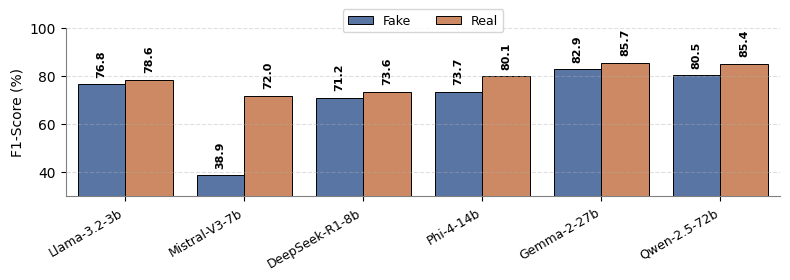

In [53]:
# classwise performance
classwise_plot_fake(df_fz,'4_fake_classwise_zero',y_limit=[30,100],save = True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_31176\916200609.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  splot = sns.barplot(


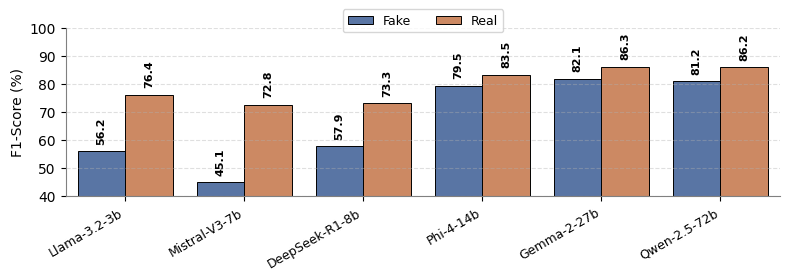

In [54]:
# classwise performance
classwise_plot_fake(df_ff,'4_fake_classwise_few',y_limit=[40,100],save = True)

### Ã°Å¸â€œâ€° Confusion Matrix

In [55]:
## Confusion matrix function
def con_mat_fake(cm, class_names,model_name):
    plt.figure(figsize=(4, 3))  # Ã°Å¸â€Â¹ Bigger and clearer
    ax = plt.subplot()

    # Ã°Å¸â€Â¹ Use dark blue color map ('Blues' similar to your provided image)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        annot_kws={"size": 12, "weight": "bold"},
        square=True,
        cbar=True,
        linewidths=0.4,
        linecolor='white'
    )

    # Ã°Å¸â€Â¹ Label settings
    ax.set_xlabel("Predicted label", fontsize=11, labelpad=6)
    ax.set_ylabel("True label", fontsize=11, labelpad=6)

    ax.xaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')
    ax.yaxis.set_ticklabels(class_names, rotation=0, fontsize=10, weight='bold')

    # Ã°Å¸â€Â¹ Adjust layout
    plt.tight_layout()

    # Ã°Å¸â€Â¹ Save high-quality figure
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, f"{model_name}.png"), dpi=600, bbox_inches='tight')

    plt.show()
    plt.close()



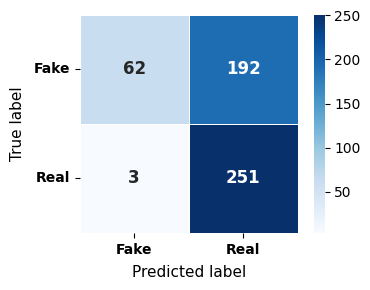

In [56]:
## zero shot worst model
v_model = confusion_matrix(zero_fake['label'],zero_fake['mistral-7B'])
class_names =['Fake','Real']
con_mat_fake(v_model, class_names,"4_fake_mistral_conf_zero_worst_model")
#v_model

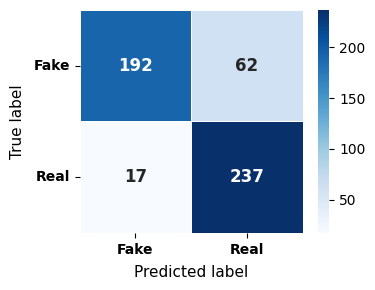

In [57]:
## zero shot best model
v_model = confusion_matrix(zero_fake['label'],zero_fake['gemma2-27B'])
class_names =['Fake','Real']
con_mat_fake(v_model, class_names,"4_fake_gemma_conf_zero_best_model")
#v_model

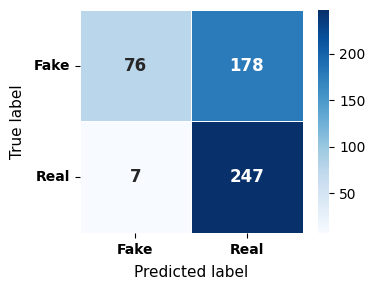

In [58]:
## few shot worst model

v_model = confusion_matrix(few_fake['label'],few_fake['mistral-7B'])
class_names =['Fake','Real']
con_mat_fake(v_model, class_names,"4_fake_mistral_conf_few_worst_model")
#v_model

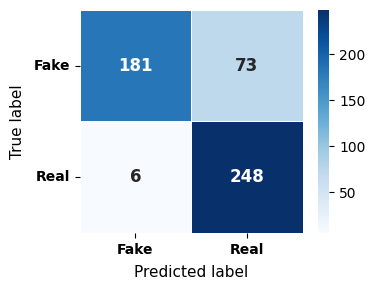

In [59]:
## few shot best model
v_model = confusion_matrix(few_fake['label'],few_fake['gemma2-27B'])
class_names =['Fake','Real']
con_mat_fake(v_model, class_names,"4_fake_gemma_conf_few_best_model")
#v_model

## Summary Chart

In [60]:
## sentiment analysis
sz = [('llama32-3B', '51.83'),('mistral-7B', '52.25'), ('deepseek-8B', '52.15'), ('phi4-14B', '60.28'), ('gemma2-27B', '61.54'), ('qwen-72B', '59.32')]
sf = [('llama32-3B', '57.19'),('mistral-7B', '49.71'), ('deepseek-8B', '51.71'), ('phi4-14B', '58.88'), ('gemma2-27B', '63.00'), ('qwen-72B', '61.30')]
# emotion recognition
ez = [('llama32-3B', '44.28'),('mistral-7B', '33.89'), ('deepseek-8B', '42.14'),('phi4-14B', '56.96'),('gemma2-27B', '58.40'), ('qwen-72B', '59.44')]
ef = [('llama32-3B', '47.12'), ('mistral-7B', '46.41'), ('deepseek-8B', '43.41'),('phi4-14B', '54.56'),('gemma2-27B', '60.27'),('qwen-72B', '65.86')]
# hate speech
hz = [('llama32-3B', '54.22'),('mistral-7B', '64.19'), ('deepseek-8B', '56.40'), ('phi4-14B', '72.17'),('gemma2-27B', '76.11'),('qwen-72B', '79.88')]
hf = [('llama32-3B', '62.85'),('mistral-7B', '63.07'), ('deepseek-8B', '61.47'),('phi4-14B', '70.56'),('gemma2-27B', '73.39'),('qwen-72B', '78.25')]
# fake news
fz = [('llama32-3B', '77.72'),('mistral-7B', '55.45'),('deepseek-8B', '72.39'),('phi4-14B', '76.91'),('gemma2-27B', '84.33'), ('qwen-72B', '82.91')]
ff = [('llama32-3B', '66.27'),('mistral-7B', '58.93'), ('deepseek-8B', '65.59'), ('phi4-14B', '81.48'), ('gemma2-27B', '84.17'),('qwen-72B', '83.68')]

In [61]:
# Combine your data
data = {
    ('Sentiment', 'zero-shot'): sz,
    ('Sentiment', 'few-shot'): sf,
    ('Emotion', 'zero-shot'): ez,
    ('Emotion', 'few-shot'): ef,
    ('Hate Speech', 'zero-shot'): hz,
    ('Hate Speech', 'few-shot'): hf,
    ('Fake News', 'zero-shot'): fz,
    ('Fake News', 'few-shot'): ff,
}

# Build a flat list of records
records = []
for (task, setting), values in data.items():
    for llm, score in values:
        records.append({
            "Dataset": task,
            "Setting": setting,
            "LLM": llm,
            "F1-Score": float(score)
        })

df = pd.DataFrame(records)
print(df.head())


     Dataset    Setting          LLM  F1-Score
0  Sentiment  zero-shot   llama32-3B     51.83
1  Sentiment  zero-shot   mistral-7B     52.25
2  Sentiment  zero-shot  deepseek-8B     52.15
3  Sentiment  zero-shot     phi4-14B     60.28
4  Sentiment  zero-shot   gemma2-27B     61.54


In [62]:
df

,Dataset,Setting,LLM,F1-Score
0,Sentiment,zero-shot,llama32-3B,51.83
1,Sentiment,zero-shot,mistral-7B,52.25
2,Sentiment,zero-shot,deepseek-8B,52.15
3,Sentiment,zero-shot,phi4-14B,60.28
4,Sentiment,zero-shot,gemma2-27B,61.54
5,Sentiment,zero-shot,qwen-72B,59.32
6,Sentiment,few-shot,llama32-3B,57.19
7,Sentiment,few-shot,mistral-7B,49.71
8,Sentiment,few-shot,deepseek-8B,51.71
9,Sentiment,few-shot,phi4-14B,58.88


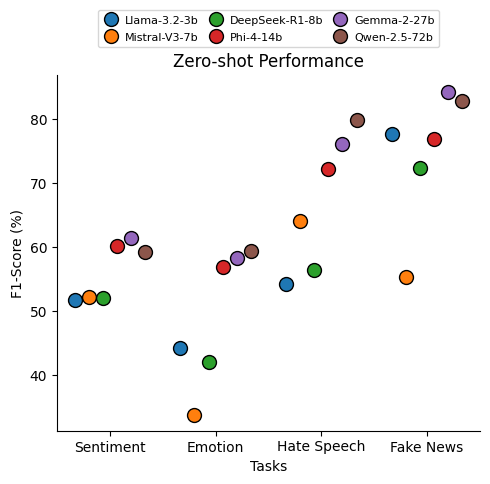

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(5, 5))
sns.stripplot(data=df[df["Setting"] == "zero-shot"], x="Dataset", y="F1-Score", hue="LLM", 
              jitter=2, dodge=1.5, size=10, palette="tab10",
              edgecolor="black",  # Border for each point
              linewidth=1)
plt.title("Zero-shot Performance")
plt.xlabel('Tasks')
plt.ylabel("F1-Score (%)")

# Remove the figure border box
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#plt.gca().spines['left'].set_visible(False)
#plt.gca().spines['bottom'].set_visible(False)

# Relabel the legends
new_labels = ['Llama-3.2-3b', 'Mistral-V3-7b', 'DeepSeek-R1-8b', 'Phi-4-14b', 'Gemma-2-27b', 'Qwen-2.5-72b']
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=new_labels, loc='upper center', bbox_to_anchor=(0.5, 1.2),
           shadow=False, ncol=3, fontsize=8, handletextpad=0.5, columnspacing=0.8, handlelength=1.5, handleheight=1.2)


# Adjust layout and display the plot
plt.tight_layout()
plt.savefig(os.path.join(results_dir,"5_zero_shot.png"),bbox_inches='tight',dpi =500)
plt.show()



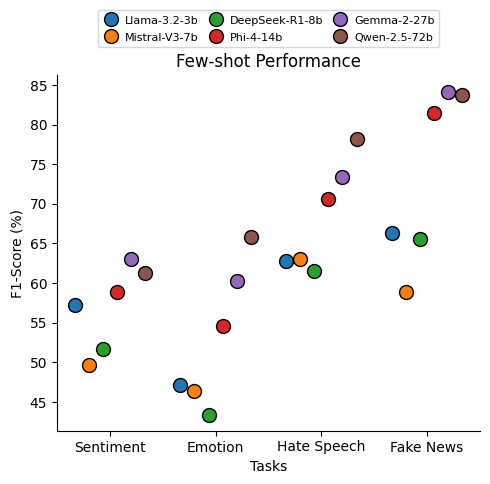

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(5, 5))
sns.stripplot(data=df[df["Setting"] == "few-shot"], x="Dataset", y="F1-Score", hue="LLM", 
              jitter=True, dodge=True, size=10, palette="tab10",
              edgecolor="black",  # Border for each point
              linewidth=1)
plt.title("Few-shot Performance")
plt.xlabel('Tasks')
plt.ylabel("F1-Score (%)")

# Remove the figure border box
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#plt.gca().spines['left'].set_visible(False)
#plt.gca().spines['bottom'].set_visible(False)

# Relabel the legends
new_labels = ['Llama-3.2-3b', 'Mistral-V3-7b', 'DeepSeek-R1-8b', 'Phi-4-14b', 'Gemma-2-27b', 'Qwen-2.5-72b']
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=new_labels, loc='upper center', bbox_to_anchor=(0.5, 1.2),
           shadow=False, ncol=3, fontsize=8, handletextpad=0.5, columnspacing=0.8, handlelength=1.5, handleheight=1.2)


# Adjust layout and display the plot
plt.tight_layout()
plt.savefig(os.path.join(results_dir,"6_few_shot.png"),bbox_inches='tight',dpi =500)
plt.show()



Ã¢Å“â€¦ Processing SENTI - Zero Shot


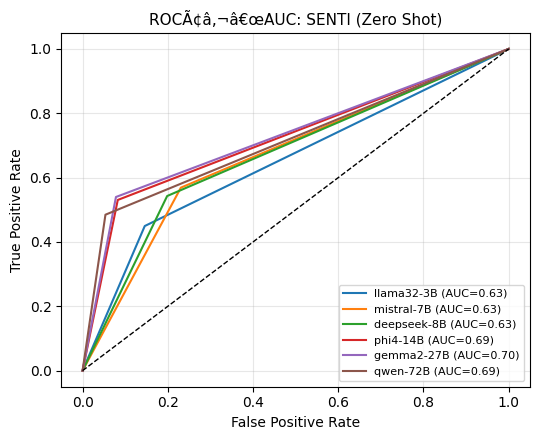

Ã¢Å“â€¦ Processing SENTI - Few Shot


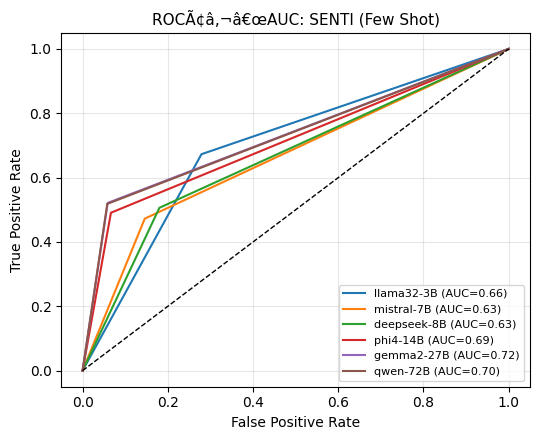

Ã¢Å“â€¦ Processing EMO - Zero Shot


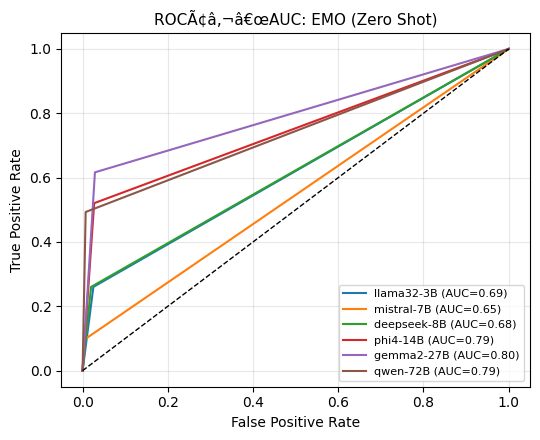

Ã¢Å“â€¦ Processing EMO - Few Shot


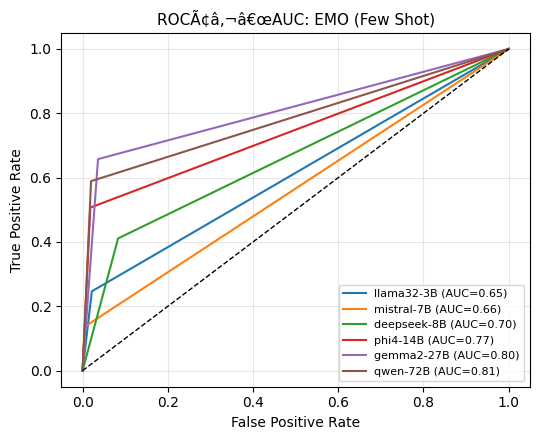

Ã¢Å“â€¦ Processing HATE - Zero Shot


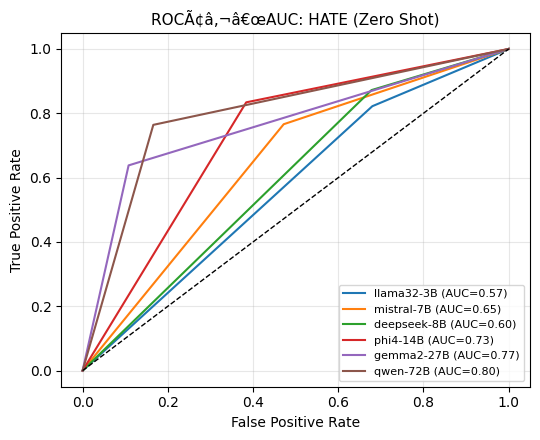

Ã¢Å“â€¦ Processing HATE - Few Shot


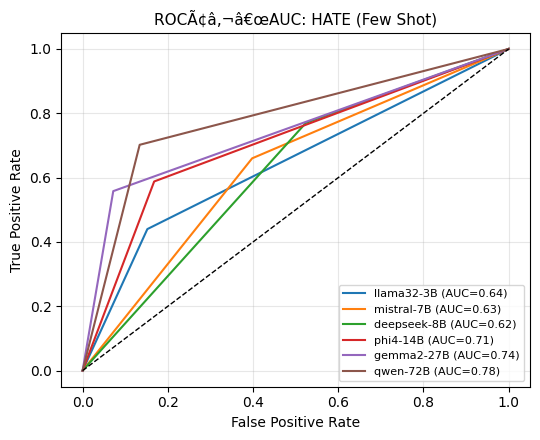

Ã¢Å“â€¦ Processing FAKE - Zero Shot


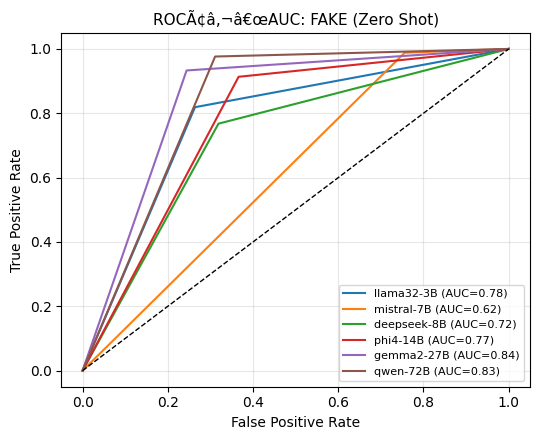

Ã¢Å“â€¦ Processing FAKE - Few Shot


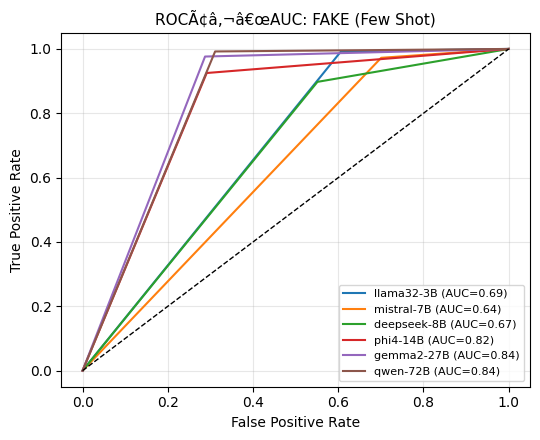

In [65]:
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ------------------- CONFIG -------------------
llm_names = ['llama32-3B', 'mistral-7B', 'deepseek-8B', 'phi4-14B', 'gemma2-27B', 'qwen-72B']
datasets = ['senti', 'emo', 'hate', 'fake']
modes = ['zero_shot', 'few_shot']

current_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
results_dir = os.path.join(root_dir, 'Results')
os.makedirs(results_dir, exist_ok=True)

# Dataset class labels
class_labels = {
    'senti': ['negative', 'neutral', 'positive'],
    'emo': ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise'],
    'hate': ['hate', 'not_hate'],
    'fake': ['fake', 'real']
}

# ------------------- ROC FUNCTION -------------------
def plot_roc_auc(df, dataset_name, mode, class_names, show=True):
    plt.figure(figsize=(5.5, 4.5))
    encoder = LabelEncoder()
    y_true = encoder.fit_transform(df['label'])
    y_true_bin = label_binarize(y_true, classes=np.unique(y_true))

    for model in llm_names:
        if model not in df.columns:
            continue

        y_pred = encoder.transform(df[model])
        y_pred_bin = label_binarize(y_pred, classes=np.unique(y_true))

        # Compute ROC curve and AUC
        roc_auc_list = []
        for i in range(y_true_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
            roc_auc_list.append(auc(fpr, tpr))

        mean_auc = np.mean(roc_auc_list)
        plt.plot(fpr, tpr, lw=1.5, label=f"{model} (AUC={mean_auc:.2f})")

    # Plot format
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate', fontsize=10)
    plt.ylabel('True Positive Rate', fontsize=10)
    plt.title(f"ROCÃ¢â‚¬â€œAUC: {dataset_name.upper()} ({mode.replace('_', ' ').title()})", fontsize=11)
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save figure
    save_path = os.path.join(results_dir, f"roc_{dataset_name}_{mode}.png")
    plt.savefig(save_path, dpi=500, bbox_inches='tight')

    # Show in notebook
    if show:
        plt.show()
    else:
        plt.close()

# ------------------- GENERATE & DISPLAY ALL -------------------
for dataset in datasets:
    for mode in modes:
        file_path = os.path.join(results_dir, f"{dataset}_{mode}.xlsx")
        if os.path.exists(file_path):
            print(f"Ã¢Å“â€¦ Processing {dataset.upper()} - {mode.replace('_',' ').title()}")
            df = pd.read_excel(file_path)
            plot_roc_auc(df, dataset, mode, class_labels[dataset], show=True)
        else:
            print(f"Ã¢Å¡Â Ã¯Â¸Â Missing file: {file_path}")